In [32]:
import pandas as pd
df = pd.read_csv('stat4_2013_2026_metadata.csv')
top_2_11_topics = df['primary_topic'].value_counts()[1:11].index.tolist()
print("锁定的十大领域：", top_2_11_topics)
df_new = df[df['primary_topic'].isin(top_2_11_topics)].copy()
df_new['institution_names'] = df_new['institution_names'].fillna('').astype(str)
df_new['institution_list'] = df_new['institution_names'].str.split(r'\s*\|\s*')
df_exploded = df_new.explode('institution_list')
df_exploded['institution_list'] = df_exploded['institution_list'].str.strip()
df_exploded = df_exploded[df_exploded['institution_list'] != '']


# 构建严密的 H 指数推导函数
def calc_h_index(citations):
    cites = sorted([c for c in citations if pd.notnull(c)], reverse=True)
    h = 0
    for i, c in enumerate(cites):
        if c >= i + 1:
            h = i + 1
        else:
            break
    return h

results = []
for topic in top_2_11_topics:
    topic_data = df_exploded[df_exploded['primary_topic'] == topic]
    if topic_data.empty:
        continue
    
    group = topic_data.groupby('institution_list')['cited_by_count'].apply(list).reset_index()
    
    group['h_index'] = group['cited_by_count'].apply(calc_h_index)
    group['total_citations'] = group['cited_by_count'].apply(lambda x: sum([c for c in x if pd.notnull(c)]))
 
    top_inst = group.sort_values(by=['h_index', 'total_citations'], ascending=[False, False]).iloc[0]
    
    results.append({
        '学术领域': topic,
        '主导机构': top_inst['institution_list'],
        '领域H指数': top_inst['h_index']
    })

# 以宏观视角呈现十个领域的最终实力版图
macro_impact_df = pd.DataFrame(results)
print(macro_impact_df)
#整体平均引用次数是多少
average_citations = df['cited_by_count'].mean()
print(f"整体平均引用次数: {average_citations:.2f}")

锁定的十大领域： ['Advanced Causal Inference Techniques', 'Bayesian Methods and Mixture Models', 'Advanced Statistical Methods and Models', 'Statistical Methods in Clinical Trials', 'Statistical Methods and Bayesian Inference', 'Financial Risk and Volatility Modeling', 'Random Matrices and Applications', 'Complex Network Analysis Techniques', 'Markov Chains and Monte Carlo Methods', 'Sparse and Compressive Sensing Techniques']
                                         学术领域                        主导机构  \
0        Advanced Causal Inference Techniques          Harvard University   
1         Bayesian Methods and Mixture Models             Duke University   
2     Advanced Statistical Methods and Models         Columbia University   
3      Statistical Methods in Clinical Trials  University of Pennsylvania   
4  Statistical Methods and Bayesian Inference             Duke University   
5      Financial Risk and Volatility Modeling      Ruhr University Bochum   
6            Random Matrices and Appli

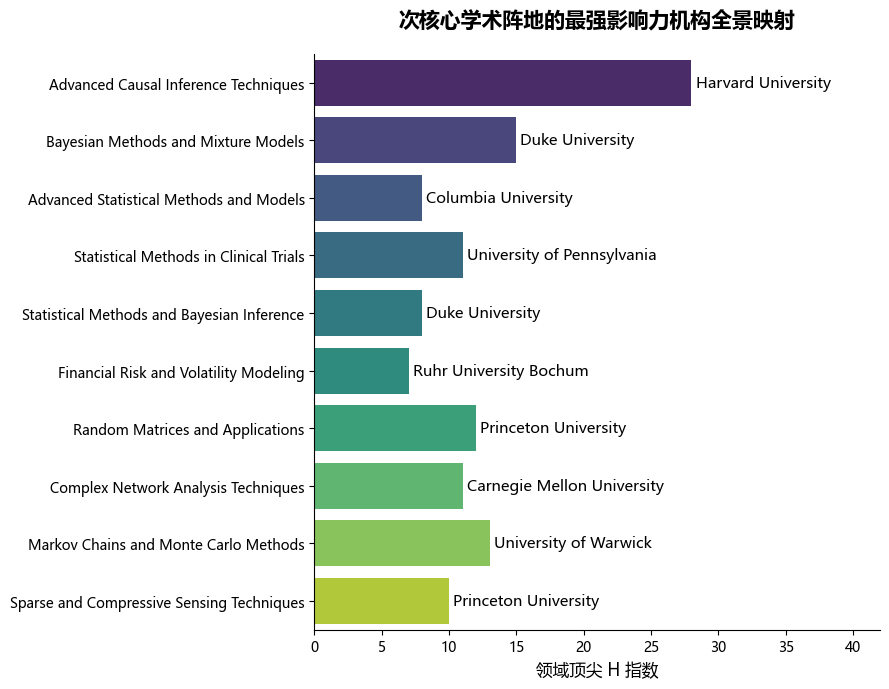

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 全局挂载 Windows 11 原生的雅黑与黑体字库
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False 
plt.figure(figsize=(9, 7))
ax = sns.barplot(
    data=macro_impact_df, 
    x='领域H指数', 
    y='学术领域', 
    hue='学术领域',
    palette='viridis',
    legend=False
)

for i, p in enumerate(ax.patches):
    inst_name = macro_impact_df.iloc[i]['主导机构']
    ax.text(
        p.get_width() + 0.3, 
        p.get_y() + p.get_height() / 2, 
        f'{inst_name}', 
        va='center', 
        ha='left', 
        color='black', 
        fontsize=11
    )

# 剥离视觉边框与标签配置
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.title('次核心学术阵地的最强影响力机构全景映射', fontsize=15, pad=20, weight='bold')
plt.xlabel('领域顶尖 H 指数', fontsize=12)
plt.ylabel('')

plt.xlim(0, macro_impact_df['领域H指数'].max() * 1.5)
plt.tight_layout()

plt.savefig('macro_institution_impact.png', dpi=300, bbox_inches='tight')
plt.show()